In [2]:
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import pandas as pd
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from transformers import (
    DeformableDetrConfig, 
    DeformableDetrForObjectDetection, 
    DeformableDetrImageProcessor
)
from PIL import Image
import matplotlib.pyplot as plt

# Ensure pycocotools is installed.
!python -c "import pycocotools" || pip install pycocotools
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# Set device (e.g., Kaggle GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

2025-05-16 02:15:16.396098: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747361716.610565      98 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747361716.670398      98 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# 1. Helper Functions

In [25]:
def load_image(image_path):
    return Image.open(image_path).convert("RGB")

def compute_iou(boxA, boxB):
    # Boxes in [xmin, ymin, xmax, ymax] format.
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6)
    return iou

def build_state(box, score, image_width, image_height):
    """
    Build a normalized state from a box (in pixel coordinates) and a score.
    Returns a vector: [xmin/image_width, ymin/image_height, width/image_width, height/image_height, score]
    """
    xmin, ymin, xmax, ymax = box.tolist()
    width = xmax - xmin
    height = ymax - ymin
    state = torch.tensor([
        xmin / image_width,
        ymin / image_height,
        width / image_width,
        height / image_height,
        score
    ], dtype=torch.float32, device=box.device)
    return state

def apply_action(box, action, image_width, image_height, shift_frac=0.01, scale_frac=0.05):
    """
    Apply an action to a candidate bounding box.
    First, convert the box to normalized coordinates; then update based on action;
    finally convert back to pixel space.
    
    Actions:
      0: shift left, 1: shift right, 2: shift up, 3: shift down,
      4: scale up, 5: scale down, 6: increase width, 7: decrease width,
      8: STOP (no change)
    """
    xmin, ymin, xmax, ymax = box.tolist()
    norm_box = torch.tensor([
        xmin / image_width,
        ymin / image_height,
        xmax / image_width,
        ymax / image_height
    ], device=box.device)
    w = norm_box[2] - norm_box[0]
    h = norm_box[3] - norm_box[1]
    
    if action == 0:  # shift left
        norm_box[0] -= shift_frac
        norm_box[2] -= shift_frac
    elif action == 1:  # shift right
        norm_box[0] += shift_frac
        norm_box[2] += shift_frac
    elif action == 2:  # shift up
        norm_box[1] -= shift_frac
        norm_box[3] -= shift_frac
    elif action == 3:  # shift down
        norm_box[1] += shift_frac
        norm_box[3] += shift_frac
    elif action == 4:  # scale up
        norm_box[0] -= scale_frac * w
        norm_box[1] -= scale_frac * h
        norm_box[2] += scale_frac * w
        norm_box[3] += scale_frac * h
    elif action == 5:  # scale down
        norm_box[0] += scale_frac * w
        norm_box[1] += scale_frac * h
        norm_box[2] -= scale_frac * w
        norm_box[3] -= scale_frac * h
    elif action == 6:  # increase width
        norm_box[0] -= scale_frac * w
        norm_box[2] += scale_frac * w
    elif action == 7:  # decrease width
        norm_box[0] += scale_frac * w
        norm_box[2] -= scale_frac * w
    # Action 8: STOP—no change.
    
    norm_box = norm_box.clamp(0, 1)
    new_box = torch.tensor([
        norm_box[0] * image_width,
        norm_box[1] * image_height,
        norm_box[2] * image_width,
        norm_box[3] * image_height
    ], device=box.device)
    return new_box

def convert_coco_bbox_to_xyxy(bbox):
    x, y, w, h = bbox
    return [x, y, x + w, y + h]

# 2. Load Pretrained Model and Define Datasets

In [4]:
model_id = "SenseTime/deformable-detr"

# (a) Load the processor.
processor = DeformableDetrImageProcessor.from_pretrained(model_id)

# (b) Download raw weights (PyTorch .bin) via torch.hub.
checkpoint_url = f"https://huggingface.co/{model_id}/resolve/main/pytorch_model.bin"
state_dict = torch.hub.load_state_dict_from_url(
    checkpoint_url,
    map_location="cpu",
    progress=True
)

# (c) Instantiate an empty model from its config.
config = DeformableDetrConfig.from_pretrained(model_id)
model = DeformableDetrForObjectDetection(config)

# (d) Load weights with assign=True.
model.load_state_dict(state_dict, strict=False, assign=True)

# (e) Move model to device and set evaluation mode.
model.to(device)
model.eval()

# (f) Define transform for torchvision datasets (keep original size).
transform = transforms.Compose([transforms.ToTensor()])

# (g) Set paths for COCO mini dataset (update these paths as necessary).
train_img_dir = "/kaggle/input/coco-2017-dataset/coco2017/train2017"
train_annFile = "/kaggle/input/coco-2017-dataset/coco2017/annotations/instances_train2017.json"
val_img_dir = "/kaggle/input/coco-2017-dataset/coco2017/val2017"
val_annFile = "/kaggle/input/coco-2017-dataset/coco2017/annotations/instances_val2017.json"

# (h) Create COCO datasets using torchvision's CocoDetection.
train_dataset = datasets.CocoDetection(root=train_img_dir, annFile=train_annFile, transform=transform)
val_dataset = datasets.CocoDetection(root=val_img_dir, annFile=val_annFile, transform=transform)

# #comment if use subset json
# # (i) Create data loaders.
# train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True,collate_fn=lambda x: tuple(zip(*x)))
# val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False,collate_fn=lambda x: tuple(zip(*x)))

loading annotations into memory...
Done (t=19.77s)
creating index...
index created!
loading annotations into memory...
Done (t=2.38s)
creating index...
index created!


In [ ]:
print(model.config.d_model)

# 3. Create a Subset JSON (Low mAP for Medium/Small)
For our purposes we iterate over a limited number (e.g., 10000) of training images, computing an average IoU for ground-truth boxes (with area < 9216, i.e., small/medium).\
Images where the average IoU is below a threshold (e.g., 0.5) are saved into a subset JSON.

In [5]:
# subset_details = []
# processed_images = 0
# subset_threshold = 0.5  # Average IoU threshold.
# max_process = 10000       # Process at most 100 images.

# print("Generating subset (low mAP on medium/small objects) from training set...")
# for images, targets in train_loader:
#     for image, target in zip(images, targets):
#         if processed_images >= max_process:
#             break
#         pil_img = transforms.ToPILImage()(image)
#         image_width, image_height = pil_img.size

#         # Run baseline detection.
#         inputs = processor(images=pil_img, return_tensors="pt").to(device)
#         with torch.no_grad():
#             outputs = model(**inputs)
#         pred_boxes = outputs.pred_boxes[0].clone()
#         pred_boxes[:, [0, 2]] *= image_width
#         pred_boxes[:, [1, 3]] *= image_height

#         # Filter GT annotations for small/medium objects (area < 9216).
#         gm_boxes = []
#         for ann in target:
#             if "bbox" in ann and "area" in ann and ann["area"] < 9216:
#                 gm_boxes.append(convert_coco_bbox_to_xyxy(ann["bbox"]))
#         if len(gm_boxes) == 0:
#             processed_images += 1
#             continue

#         # Compute maximum IoU for each GT box.
#         iou_list = []
#         for gt_box in gm_boxes:
#             max_iou = 0.0
#             for box in pred_boxes:
#                 iou = compute_iou(gt_box, box.tolist())
#                 max_iou = max(max_iou, iou)
#             iou_list.append(max_iou)
#         avg_iou = float(np.mean(iou_list)) if iou_list else 0.0

#         if avg_iou < subset_threshold:
#             if len(target) > 0:
#                 image_id = target[0].get("image_id", processed_images)
#             else:
#                 image_id = processed_images
#             if image_id in train_dataset.coco.imgs:
#                 info = train_dataset.coco.imgs[image_id]
#             else:
#                 info = {"id": image_id, "file_name": f"{image_id:012d}.jpg",
#                         "width": image_width, "height": image_height}
#             subset_details.append(info)
#         processed_images += 1
#     if processed_images >= max_process:
#         break

# subset_json_path = "low_mAP_medium_small_subset.json"
# with open(subset_json_path, "w") as f:
#     json.dump(subset_details, f)
# print(f"Subset generated with {len(subset_details)} images (out of {processed_images}) saved to {subset_json_path}")

# 4. Create a Subset Training Dataset Using the JSON

In [6]:
# Define the path to the uploaded low mAP JSON file.
subset_json_path = "/kaggle/input/low-map-subset/low_mAP_medium_small_subset.json"

# Load the JSON file containing the subset details.
with open(subset_json_path, "r") as f:
    subset_details = json.load(f)
print(f"Loaded subset JSON with {len(subset_details)} image entries.")

# Create a custom CocoDetection subset class that uses the loaded image IDs.
class CocoSubset(datasets.CocoDetection):
    def __init__(self, root, annFile, subset_info, transform=None):
        super(CocoSubset, self).__init__(root, annFile, transform)
        # Extract the image IDs from the subset_info.
        subset_ids = {item["id"] for item in subset_info}
        # Filter the dataset image IDs to include only those in the subset.
        self.ids = [img_id for img_id in self.ids if img_id in subset_ids]

# Now instantiate your subset training dataset using the loaded JSON.
subset_train_dataset = CocoSubset(train_img_dir, train_annFile, subset_details, transform=transform)
subset_train_loader = DataLoader(
    subset_train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=lambda x: tuple(zip(*x))
)
print(f"Subset training dataset loaded with {len(subset_train_dataset)} images.")

Loaded subset JSON with 7654 image entries.
loading annotations into memory...
Done (t=16.49s)
creating index...
index created!
Subset training dataset loaded with 7654 images.


# 5. Define the RL Agent (Deep Q-Network)

In [26]:
class BoxRefinementAgent(nn.Module):
    def __init__(self, input_dim, action_dim):
        super(BoxRefinementAgent, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )
    def forward(self, state):
        return self.fc(state)

# Note: Since the state is now a 5-d vector (all normalized) and a reasonable score,
# we want the outputs to be in a similar scale. Using reward_scale=1.0 ensures that
# reward (which is just the IoU) remains in the range [0,1].
agent = BoxRefinementAgent(input_dim=5, action_dim=9).to(device)
optimizer_rl = optim.Adam(agent.parameters(), lr=1e-4)

# 6. RL Training on the Subset

In [18]:
# MAX_STEPS = 3
# STOP_ACTION = 8
# num_rl_iterations = 10   # (Increase for real training)
# gamma = 0.9
# epsilon = 0.2  # initial exploration rate

# # Set how many batches you want to process per iteration.
# max_batches = 500  # For example, if batch size is 2, 50 batches process 100 images.

# print("Starting RL training on the subset training dataset...")

# for iteration in range(num_rl_iterations):
#     cumulative_loss = 0.0
#     count_updates = 0
#     for batch_idx, (images, targets) in enumerate(subset_train_loader):
#         # Stop if we've processed the desired number of batches.
#         if batch_idx >= max_batches:
#             break

#         for image, target in zip(images, targets):
#             pil_img = transforms.ToPILImage()(image)
#             image_width, image_height = pil_img.size

#             # Process the image using the processor; the processor will convert from normalized to pixel coordinates.
#             inputs = processor(images=pil_img, return_tensors="pt").to(device)
#             with torch.no_grad():
#                 outputs = model(**inputs)
            
#             target_sizes = torch.tensor([pil_img.size[::-1]], device=device)  # [height, width]
#             post_results = processor.post_process_object_detection(
#                 outputs, threshold=0.05, target_sizes=target_sizes
#             )[0]
#             pred_boxes = post_results["boxes"]    # Already in pixel coordinates.
#             pred_scores = post_results["scores"]
            
#             # Prepare ground-truth boxes (for small/medium objects).
#             gt_boxes = []
#             for ann in target:
#                 if "bbox" in ann and "area" in ann and ann["area"] < 9216:
#                     gt_boxes.append(convert_coco_bbox_to_xyxy(ann["bbox"]))
#             if not gt_boxes:
#                 continue
#             gt_boxes = [torch.tensor(b, device=device, dtype=torch.float32) for b in gt_boxes]

#             # Loop through candidate predictions (usually out of 300 queries).
#             for i, score in enumerate(pred_scores):
#                 score_val = score.item()
#                 # For example, select candidates with moderate confidence.
#                 if score_val < 0.05 or score_val > 0.9:
#                     continue

#                 box = pred_boxes[i]
#                 best_iou = 0.0
#                 best_gt = None
#                 for gt_box in gt_boxes:
#                     iou_val = compute_iou(box.tolist(), gt_box.tolist())
#                     if iou_val > best_iou:
#                         best_iou = iou_val
#                         best_gt = gt_box
#                 if best_gt is None:
#                     continue

#                 # Build state (the geometry and score).
#                 state = build_state(box, score_val)
#                 # RL refinement loop
#                 for step in range(MAX_STEPS):
#                     if np.random.rand() < epsilon:
#                         action = np.random.choice(9)
#                     else:
#                         q_values = agent(state)
#                         action = torch.argmax(q_values).item()
#                     if action == STOP_ACTION:
#                         break
#                     new_box = apply_action(box, action)
#                     new_state = build_state(new_box, score_val)
#                     # Reward based on improved IoU.
#                     reward = compute_iou(new_box.tolist(), best_gt.tolist())
#                     with torch.no_grad():
#                         next_q = torch.max(agent(new_state)).item()
#                     target_q = reward + gamma * next_q
#                     predicted_q = agent(state)[action]
#                     loss = F.mse_loss(predicted_q, torch.tensor(target_q, device=device))
#                     cumulative_loss += loss
#                     count_updates += 1
#                     # Update box and corresponding state.
#                     box = new_box
#                     state = new_state

#             torch.cuda.empty_cache()  # Free GPU memory if needed.
    
#     if count_updates > 0:
#         optimizer_rl.zero_grad()
#         cumulative_loss.backward()
#         optimizer_rl.step()
#     epsilon = max(0.05, epsilon * 0.99)
#     avg_loss = cumulative_loss.item() / count_updates if count_updates > 0 else 0
#     print(f"Iteration {iteration+1}: Avg loss = {avg_loss:.4f} over {count_updates} updates")

Starting RL training on the subset training dataset...
Iteration 1: Avg loss = 3033.0614 over 25914 updates
Iteration 2: Avg loss = 3039.5245 over 26698 updates
Iteration 3: Avg loss = 3014.4697 over 26473 updates
Iteration 4: Avg loss = 2690.9925 over 27490 updates
Iteration 5: Avg loss = 2688.0291 over 27191 updates
Iteration 6: Avg loss = 2597.4693 over 27860 updates
Iteration 7: Avg loss = 2514.5984 over 27694 updates
Iteration 8: Avg loss = 2359.7536 over 29285 updates
Iteration 9: Avg loss = 2573.9518 over 27380 updates
Iteration 10: Avg loss = 2557.3175 over 25354 updates


In [30]:
MAX_STEPS = 3
STOP_ACTION = 8
num_rl_iterations = 10    # Try increasing gradually.
gamma = 0.9
epsilon = 0.2             # Initial exploration rate.
reward_scale = 1.0        # Lowered reward scale to align with normalized state.

# Set how many batches you want to process per iteration.
max_batches = 500  # For example, if batch size is 2, 500 batches process 1000 images.

print("Starting RL training on the subset training dataset...")

for iteration in range(num_rl_iterations):
    cumulative_loss = 0.0
    count_updates = 0
    for batch_idx, (images, targets) in enumerate(subset_train_loader):
        # Stop if we've processed the desired number of batches.
        if batch_idx >= max_batches:
            break
        
        for image, target in zip(images, targets):
            pil_img = transforms.ToPILImage()(image)
            image_width, image_height = pil_img.size   # e.g. ~640 x 425

            # Process the image.
            inputs = processor(images=pil_img, return_tensors="pt").to(device)
            with torch.no_grad():
                outputs = model(**inputs)
            
            target_sizes = torch.tensor([pil_img.size[::-1]], device=device)  # [height, width]
            post_results = processor.post_process_object_detection(
                outputs, threshold=0.05, target_sizes=target_sizes
            )[0]
            pred_boxes = post_results["boxes"]
            pred_scores = post_results["scores"]

            # Filter ground-truth boxes for small/medium objects.
            gt_boxes = []
            for ann in target:
                if "bbox" in ann and "area" in ann and ann["area"] < 9216:
                    gt_boxes.append(convert_coco_bbox_to_xyxy(ann["bbox"]))
            if not gt_boxes:
                continue
            gt_boxes = [torch.tensor(b, device=device, dtype=torch.float32) for b in gt_boxes]

            for i, score in enumerate(pred_scores):
                score_val = score.item()
                if score_val < 0.05 or score_val > 0.9:
                    continue

                box = pred_boxes[i]
                best_iou = 0.0
                best_gt = None
                for gt_box in gt_boxes:
                    iou_val = compute_iou(box.tolist(), gt_box.tolist())
                    if iou_val > best_iou:
                        best_iou = iou_val
                        best_gt = gt_box
                if best_gt is None:
                    continue

                # Build the normalized state.
                state = build_state(box, score_val, image_width, image_height)

                for step in range(MAX_STEPS):
                    if np.random.rand() < epsilon:
                        action = np.random.choice(9)
                    else:
                        q_values = agent(state)
                        action = torch.argmax(q_values).item()
                    if action == STOP_ACTION:
                        break
                    new_box = apply_action(box, action, image_width, image_height)
                    new_state = build_state(new_box, score_val, image_width, image_height)
                    # Reward is the IoU (reward_scale is 1.0).
                    reward = reward_scale * compute_iou(new_box.tolist(), best_gt.tolist())
                    with torch.no_grad():
                        next_q = torch.max(agent(new_state)).item()
                    target_q = reward + gamma * next_q
                    predicted_q = agent(state)[action]
                    loss = F.smooth_l1_loss(predicted_q, torch.tensor(target_q, device=device))
                    cumulative_loss += loss
                    count_updates += 1

                    # Update the box and state for the next RL step.
                    box = new_box
                    state = new_state
        
        # (Optional) Clear GPU cache after each batch.
        torch.cuda.empty_cache()

    if count_updates > 0:
        optimizer_rl.zero_grad()
        cumulative_loss.backward()
        torch.nn.utils.clip_grad_norm_(agent.parameters(), 1.0)
        optimizer_rl.step()
    epsilon = max(0.05, epsilon * 0.99)
    avg_loss = cumulative_loss.item() / count_updates if count_updates > 0 else 0
    print(f"Iteration {iteration+1}: Avg loss = {avg_loss:.4f} over {count_updates} updates")

Starting RL training on the subset training dataset...
Iteration 1: Avg loss = 0.0855 over 123540 updates
Iteration 2: Avg loss = 0.0830 over 122034 updates
Iteration 3: Avg loss = 0.0816 over 129063 updates
Iteration 4: Avg loss = 0.0819 over 129102 updates
Iteration 5: Avg loss = 0.0822 over 129871 updates
Iteration 6: Avg loss = 0.0837 over 131859 updates
Iteration 7: Avg loss = 0.0818 over 130637 updates
Iteration 8: Avg loss = 0.0819 over 136744 updates
Iteration 9: Avg loss = 0.0824 over 135030 updates
Iteration 10: Avg loss = 0.0825 over 135926 updates


# 7. Evaluation on the Validation Set

In [31]:
max_eval = 300
subset_indices = list(range(max_eval))
subset_val_dataset = Subset(val_dataset, subset_indices)
subset_val_loader = DataLoader(
    subset_val_dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=lambda x: tuple(zip(*x))
)

results_baseline = []  # Baseline detections.
results_rl = []        # RL-refined detections.

# Load ground-truth COCO annotations.
cocoGt = COCO(val_annFile)
valid_img_ids = set(cocoGt.getImgIds())
print("Total valid image IDs in ground-truth:", len(valid_img_ids))
print(f"Evaluating on {max_eval} images from the validation set...")

# Define a refine_box function that uses the updated helper functions.
def refine_box(box, score, image_width, image_height, max_steps=MAX_STEPS):
    state = build_state(box, score, image_width, image_height)
    for step in range(max_steps):
        q_values = agent(state)
        action = torch.argmax(q_values).item()
        if action == STOP_ACTION:
            break
        box = apply_action(box, action, image_width, image_height)
        state = build_state(box, score, image_width, image_height)
    return box

# Iterate through the validation subset.
for images, targets in subset_val_loader:
    for image, target in zip(images, targets):
        # Extract image_id from the target if available.
        if len(target) > 0 and "image_id" in target[0]:
            image_id = target[0]["image_id"]
        else:
            image_id = -1  # Fallback; ensure that your dataset has valid IDs.
        if image_id not in valid_img_ids:
            continue

        pil_img = transforms.ToPILImage()(image)
        image_width, image_height = pil_img.size

        # Process the image using the processor.
        inputs = processor(images=pil_img, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        
        # Define target_sizes as [height, width].
        target_sizes = torch.tensor([pil_img.size[::-1]], device=device)
        post_results = processor.post_process_object_detection(
            outputs, threshold=0.05, target_sizes=target_sizes
        )[0]  # Dictionary with keys: "boxes", "scores", "labels"

        pred_boxes = post_results["boxes"]      # shape: [num_detections, 4]
        pred_scores = post_results["scores"]
        pred_labels = post_results["labels"]

        num_preds = pred_boxes.shape[0]
        for i in range(num_preds):
            score_val = pred_scores[i].item()
            if score_val < 0.05:
                continue
            
            box = pred_boxes[i]
            width_val = (box[2] - box[0]).item()
            height_val = (box[3] - box[1]).item()
            if width_val <= 0 or height_val <= 0:
                continue

            # Baseline detection.
            bbox_baseline = [box[0].item(), box[1].item(), width_val, height_val]
            detection_baseline = {
                "image_id": image_id,
                "category_id": int(pred_labels[i].item()),
                "bbox": bbox_baseline,
                "score": score_val
            }
            results_baseline.append(detection_baseline)

            # RL-refined detection using a greedy (deterministic) policy.
            refined_box = refine_box(box, score_val, image_width, image_height, max_steps=MAX_STEPS)
            refined_width = (refined_box[2] - refined_box[0]).item()
            refined_height = (refined_box[3] - refined_box[1]).item()
            if refined_width <= 0 or refined_height <= 0:
                continue
            bbox_refined = [refined_box[0].item(), refined_box[1].item(), refined_width, refined_height]
            detection_rl = {
                "image_id": image_id,
                "category_id": int(pred_labels[i].item()),
                "bbox": bbox_refined,
                "score": score_val
            }
            results_rl.append(detection_rl)

# Save detection results to JSON files.
with open("results_baseline.json", "w") as f:
    json.dump(results_baseline, f)
with open("results_rl.json", "w") as f:
    json.dump(results_rl, f)
print("Detection results saved.")

# Evaluate using the COCO API.
cocoDt_baseline = cocoGt.loadRes("results_baseline.json")
cocoEval_baseline = COCOeval(cocoGt, cocoDt_baseline, iouType="bbox")
cocoEval_baseline.evaluate()
cocoEval_baseline.accumulate()
print("\nCOCO Evaluation Metrics for Baseline Deformable DETR:")
cocoEval_baseline.summarize()

cocoDt_rl = cocoGt.loadRes("results_rl.json")
cocoEval_rl = COCOeval(cocoGt, cocoDt_rl, iouType="bbox")
cocoEval_rl.evaluate()
cocoEval_rl.accumulate()
print("\nCOCO Evaluation Metrics for Deformable DETR + RL:")
cocoEval_rl.summarize()

loading annotations into memory...
Done (t=0.42s)
creating index...
index created!
Total valid image IDs in ground-truth: 5000
Evaluating on 300 images from the validation set...
Detection results saved.
Loading and preparing results...
DONE (t=0.09s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=9.25s).
Accumulating evaluation results...
DONE (t=1.49s).

COCO Evaluation Metrics for Baseline Deformable DETR:
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.030
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.041
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.032
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.017
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.035
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.039
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=

In [36]:
cocoEval_rl.summarize()

 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.015
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.032
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.009
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.004
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.017
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.024
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.011
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.018
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.019
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.004
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.021
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.031


In [37]:
print("RL stats:", cocoEval_rl.stats)
print("RL stats length:", len(cocoEval_rl.stats))


RL stats: [0.01521905 0.03186185 0.00857365 0.00373622 0.01710213 0.02427328
 0.01129583 0.01762214 0.01880967 0.004363   0.02059001 0.03129577]
RL stats length: 12


# 8. Build and Show a Metrics Table and Visualizations
Extract key metrics from cocoEval.stats; conventionally:\
stats[0]=mAP@[.50:.95], [1]=AP@50, [2]=AP@75, [3]=AP_small, [8]=AR@100


Summary Metrics Table:
          Metric  Baseline   With RL  Difference
0  mAP@[.50:.95]  0.029760  0.015219   -0.014541
1          AP@50  0.040977  0.031862   -0.009115
2          AP@75  0.032369  0.008574   -0.023795
3       AP_small  0.016815  0.003736   -0.013079
4         AR@100  0.035483  0.018810   -0.016673


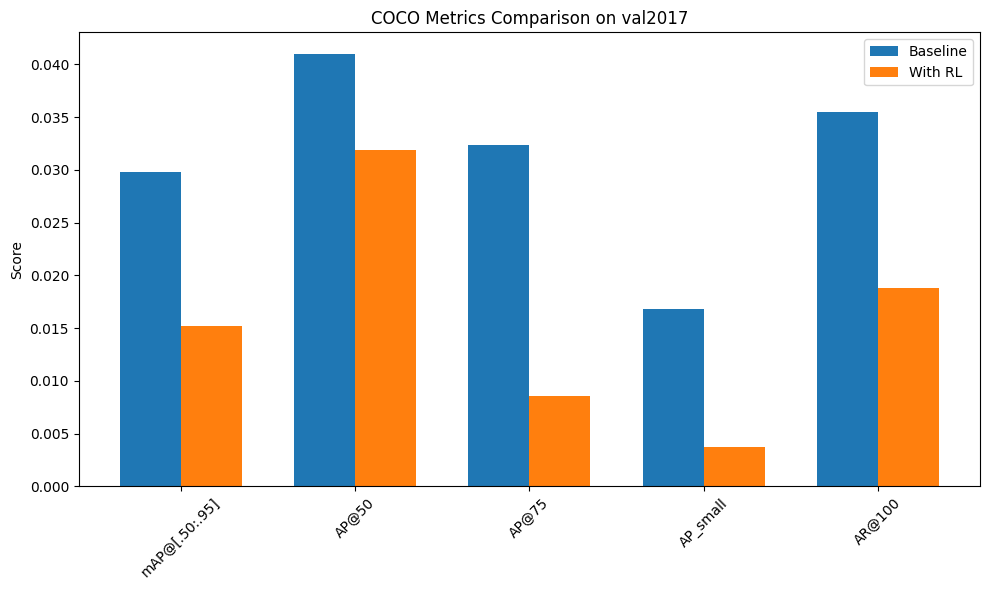

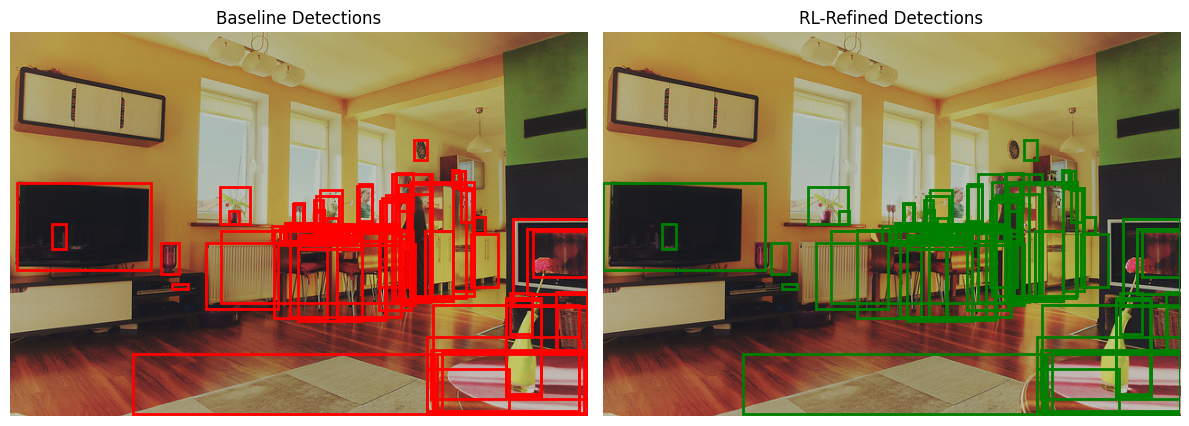

In [39]:
metric_names = ["mAP@[.50:.95]", "AP@50", "AP@75", "AP_small", "AR@100"]
baseline_values = [
    cocoEval_baseline.stats[0],
    cocoEval_baseline.stats[1],
    cocoEval_baseline.stats[2],
    cocoEval_baseline.stats[3],
    cocoEval_baseline.stats[8]
]
rl_values = [
    cocoEval_rl.stats[0],
    cocoEval_rl.stats[1],
    cocoEval_rl.stats[2],
    cocoEval_rl.stats[3],
    cocoEval_rl.stats[8]
]

df_metrics = pd.DataFrame({
    "Metric": metric_names,
    "Baseline": baseline_values,
    "With RL": rl_values,
    "Difference": [rl - base for rl, base in zip(rl_values, baseline_values)]
})
print("\nSummary Metrics Table:")
print(df_metrics)

# Plot a bar chart to visually compare the metrics.
x = np.arange(len(metric_names))
width = 0.35
plt.figure(figsize=(10,6))
plt.bar(x - width/2, baseline_values, width, label='Baseline')
plt.bar(x + width/2, rl_values, width, label='With RL')
plt.ylabel("Score")
plt.title("COCO Metrics Comparison on val2017")
plt.xticks(x, metric_names, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# # Plot training loss curve (assuming training_losses is defined).
# plt.figure(figsize=(8, 5))
# plt.plot(range(1, len(training_losses)+1), training_losses, marker='o', linestyle='-')
# plt.xlabel("Iteration")
# plt.ylabel("Average Training Loss")
# plt.title("Training Loss Curve (LSTM RL Agent)")
# plt.grid(True)
# plt.show()

# Qualitative visualization on one validation image.
def visualize_detections(pil_img, detections, color, label):
    plt.imshow(pil_img)
    ax = plt.gca()
    seen_label = False
    for det in detections:
        x, y, w, h = det["bbox"]
        # Add the label only once.
        if not seen_label:
            rect = plt.Rectangle((x, y), w, h, fill=False, edgecolor=color, linewidth=2, label=label)
            seen_label = True
        else:
            rect = plt.Rectangle((x, y), w, h, fill=False, edgecolor=color, linewidth=2)
        ax.add_patch(rect)
    plt.axis("off")

# Choose one sample from the validation set.
sample_img, sample_target = val_dataset[0]
if len(sample_target) > 0 and "image_id" in sample_target[0]:
    sample_img_id = sample_target[0]["image_id"]
else:
    sample_img_id = -1
pil_img = transforms.ToPILImage()(sample_img)
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Baseline Detections")
visualize_detections(pil_img, [det for det in results_baseline if det["image_id"] == sample_img_id], "red", "Baseline")
plt.subplot(1,2,2)
plt.title("RL-Refined Detections")
visualize_detections(pil_img, [det for det in results_rl if det["image_id"] == sample_img_id], "green", "RL")
plt.tight_layout()
plt.show()